# LeJEPA Package Showcase
This notebook demonstrates how to load backbones and run probes.

In [5]:
from lejepa_Core.Backbone_pretrain import (
    start_pretraining,
    load_lejepa,
    tile_image,
    ForageTileDataset,
    lejepa_prediction_loss
)

from lejepa_Core.visualizations import plot_class_grid

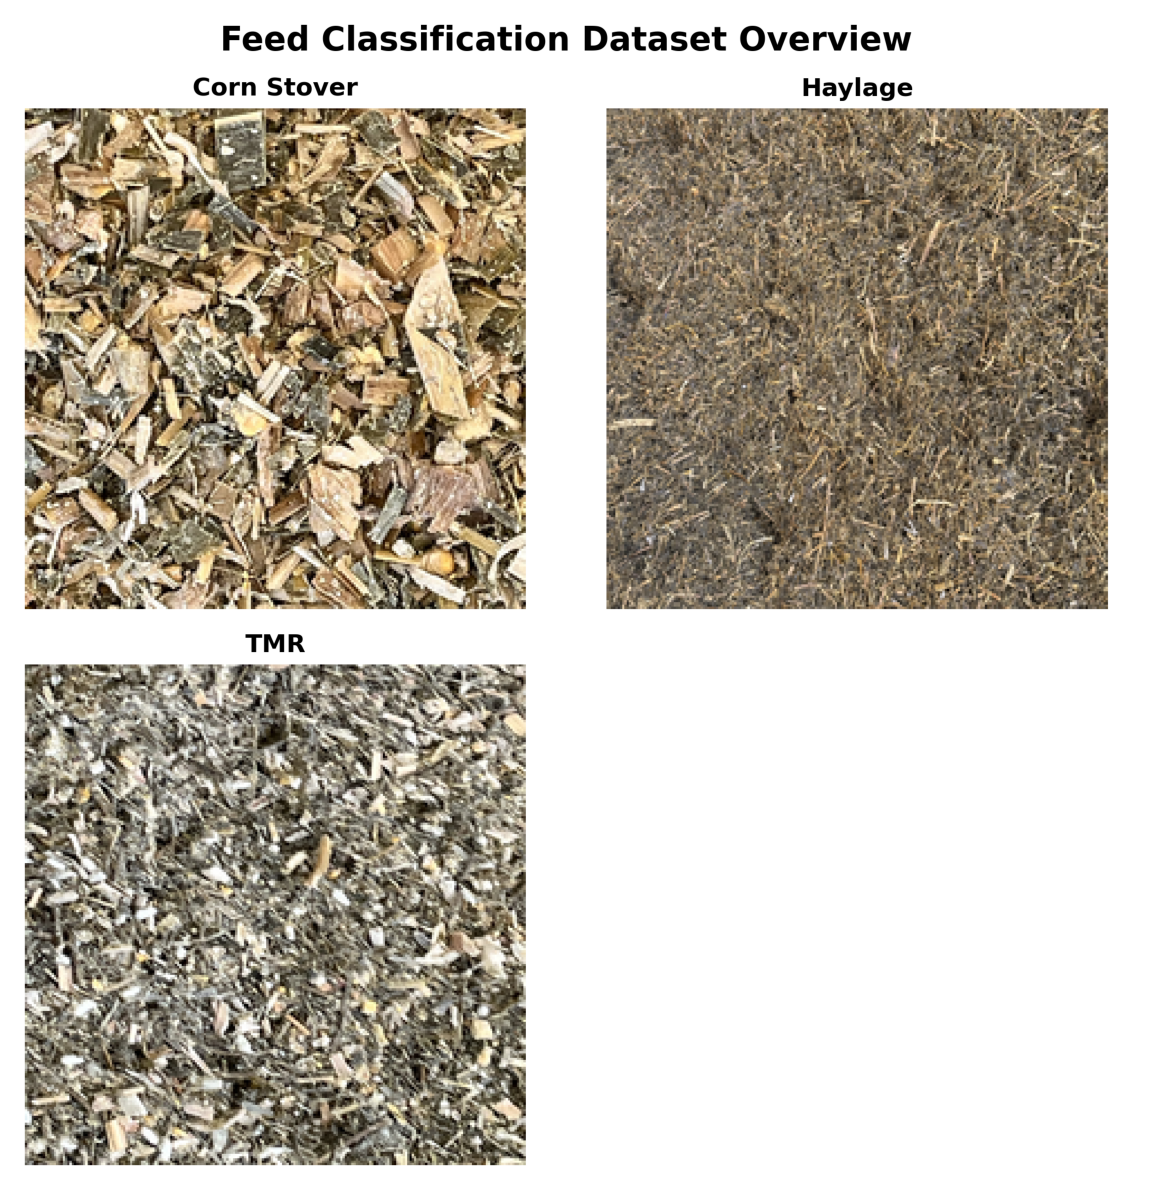

In [6]:

import os
import math
import random
from pathlib import Path
from typing import Tuple, List, Union, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
def main():
    dataset_dir = Path("/Users/akintanoreofeoluwa/Downloads/Classification dataset 2")
    output_dir = Path("/Users/akintanoreofeoluwa/Downloads/Figure")
    save_path = output_dir / "class_overview_grid.png"
 
    if not dataset_dir.exists():
        raise FileNotFoundError(f"Dataset directory not found: {dataset_dir}")
 
    output_dir.mkdir(parents=True, exist_ok=True)
 
    plot_class_grid(
        dataset_dir=dataset_dir,
        out_path=save_path,
        samples_per_class=1,
        image_size=(224, 224),
        title="Feed Classification Dataset Overview",
        seed=42,
    )
 
    # Display inline
    img = Image.open(save_path)
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
 
 
if __name__ == "__main__":
    main()

In [6]:
"""
Diagnoses why plot_class_grid only picked up one class.

Run this against your actual dataset_dir. It prints every top-level
subfolder, whether it's a directory, and how many files with a recognized
image extension it contains -- this will reveal whether other class
folders are empty, nested differently, or using an unrecognized extension.
"""

from pathlib import Path

VALID_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

dataset_dir = Path("/Users/akintanoreofeoluwa/Downloads/Classification dataset")

if not dataset_dir.exists():
    raise FileNotFoundError(f"Dataset directory not found: {dataset_dir}")

print(f"Scanning: {dataset_dir}\n")

entries = sorted(dataset_dir.iterdir())
if not entries:
    print("Directory is empty.")

for entry in entries:
    if entry.name.startswith('.'):
        print(f"[skipped - hidden] {entry.name}")
        continue

    if not entry.is_dir():
        print(f"[skipped - not a folder] {entry.name}")
        continue

    all_files = [f for f in entry.iterdir() if f.is_file()]
    valid_images = [f for f in all_files if f.suffix.lower() in VALID_EXTS]
    subfolders = [f for f in entry.iterdir() if f.is_dir()]

    print(f"[folder] {entry.name}")
    print(f"    total files: {len(all_files)}")
    print(f"    valid images (by extension): {len(valid_images)}")
    if subfolders:
        print(f"    contains {len(subfolders)} nested subfolder(s): "
              f"{[s.name for s in subfolders]}  <-- images may be nested here instead")
    if all_files and not valid_images:
        exts_found = sorted({f.suffix.lower() for f in all_files})
        print(f"    no recognized image extensions -- file extensions present: {exts_found}")
    print()

Scanning: /Users/akintanoreofeoluwa/Downloads/Classification dataset

[skipped - hidden] .DS_Store
[folder] Alfalfa Hay
    total files: 0
    valid images (by extension): 0

[folder] Corn Stover
    total files: 99
    valid images (by extension): 0
    no recognized image extensions -- file extensions present: ['.heic']

[folder] Haylage
    total files: 64
    valid images (by extension): 64

[folder] Orchard Grass
    total files: 0
    valid images (by extension): 0

[folder] TMR
    total files: 16
    valid images (by extension): 0
    no recognized image extensions -- file extensions present: ['.heic']

[folder] Timothy Grass
    total files: 0
    valid images (by extension): 0



In [6]:
from pathlib import Path

dataset_path = Path(r"/Users/akintanoreofeoluwa/Downloads/Classification dataset")
print("Found subdirectories:", [p.name for p in dataset_path.iterdir() if p.is_dir() and not p.name.startswith('.')])

Found subdirectories: ['TMR', 'Alfalfa Hay', 'Corn Stover', 'Haylage', 'Orchard Grass', 'Timothy Grass']
